<a href="https://colab.research.google.com/github/AYMAN-CHAREF/machine-learning-et-deep-learning/blob/main/TP_k_plus_proches_voisins_(KNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exercice 1 : Impl´ementation de KNN from scratch**

In [35]:
import numpy as np
from collections import Counter
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_squared_error, mean_absolute_error, r2_score



In [36]:
# Fonction KNN principale
def knn_predict(E, x, k, task='classification'):
    # Calcul des distances entre le point x et tous les points d'entraînement
    distances = np.sqrt(np.sum((E['x'] - x)**2, axis=1))

    # Sélection des indices des k plus proches voisins
    k_indices = np.argsort(distances)[:k]

    # Récupération des étiquettes des k plus proches voisins
    k_nearest_labels = E['y'][k_indices]

    # Prédiction selon le type d'application
    if task == 'classification':
        # Pour la classification, on prend la classe majoritaire
        return Counter(k_nearest_labels).most_common(1)[0][0], k_indices
    else:  # task == "regression"
        # Pour la régression, on calcule la moyenne
        return np.mean(k_nearest_labels), k_indices

In [51]:
        # Test sur Iris Dataset (Classification)

        # Chargement des données
        iris = load_iris()
        X, y = iris.data, iris.target

        # Division en ensembles d'entraînement et de test
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Préparation des données au format attendu par notre fonction
        E = {'x': X_train, 'y': y_train}

        # Application de knn_predict à chaque point de test manuellement
        predictions = []
        all_indices = []

        for x in X_test:  # Changed from X_test_raw to X_test
            pred, indices = knn_predict(E, x, k=5)
            predictions.append(pred)
            all_indices.append(indices)

        y_pred = np.array(predictions)

        # Métriques pour notre implémentation
        accuracy = accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')

        print("=== Résultats KNN sur Iris classification from scratch ===")
        print(f"Précision: {accuracy:.4f}")
        print(f"F1-score: {f1:.4f}")
        print("Matrice de confusion:")
        print(conf_matrix)

=== Résultats KNN sur Iris classification from scratch ===
Précision: 1.0000
F1-score: 1.0000
Matrice de confusion:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [49]:
 # KNN de scikit-learn
 from sklearn.neighbors import KNeighborsClassifier

 knn_sklearn= KNeighborsClassifier(n_neighbors=5)
 knn_sklearn.fit(X_train, y_train)
 y_pred_sklearn = knn_sklearn.predict(X_test)

 accuracy_sklearn= accuracy_score(y_test, y_pred_sklearn)
 conf_matrix_sklearn = confusion_matrix(y_test, y_pred_sklearn)
 f1_sklearn = f1_score(y_test, y_pred_sklearn, average='weighted')

print("\n=== Résultats KNN sur Iris avec scikit-learn ===")
print(f"Précision: {accuracy_sklearn:.4f}")
print(f"F1-score: {f1_sklearn:.4f}")
print("Matrice de confusion:")
print(conf_matrix_sklearn)



=== Résultats KNN sur Iris avec scikit-learn ===
Précision: 1.0000
F1-score: 1.0000
Matrice de confusion:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [55]:
# Test sur California Housing Dataset (Régression)

# Chargement des données
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Division en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pour accélérer les tests, prenons un sous-ensemble plus petit
X_train_sample = X_train[:1000]
y_train_sample = y_train[:1000]
X_test_sample = X_test[:200]
y_test_sample = y_test[:200]

# Préparation des données au format attendu par notre fonction
E = {'x': X_train_sample, 'y': y_train_sample}

# Application de knn_predict à chaque point de test manuellement
predictions = []
all_indices = []

for x in X_test_sample:

  pred, indices = knn_predict(E, x, k=5, task='regression')
  predictions.append(pred)
  all_indices.append(indices)

y_pred = np.array(predictions)

rmse = np.sqrt(mean_squared_error(y_test_sample, y_pred))
mae = mean_absolute_error(y_test_sample, y_pred)
r2 = r2_score(y_test_sample, y_pred)

print("=== Résultats KNN sur California Housing - regression from scratch ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")


=== Résultats KNN sur California Housing - regression from scratch ===
RMSE: 1.1319
MAE: 0.8998
R²: -0.0481


In [61]:
 # KNN de scikit-learn
from sklearn.neighbors import KNeighborsRegressor
knn_sklearn = KNeighborsRegressor(n_neighbors=5)
knn_sklearn.fit(X_train_sample, y_train_sample)
y_pred_sklearn = knn_sklearn.predict(X_test_sample)

In [62]:
rmse_sklearn = np.sqrt(mean_squared_error(y_test_sample, y_pred_sklearn))
mae_sklearn = mean_absolute_error(y_test_sample, y_pred_sklearn)
r2_sklearn = r2_score(y_test_sample, y_pred_sklearn)

print("\n=== Résultats KNN sur California Housing  (scikit-learn) ===")
print(f"RMSE: {rmse_sklearn:.4f}")
print(f"MAE: {mae_sklearn:.4f}")
print(f"R²: {r2_sklearn:.4f}")


=== Résultats KNN sur California Housing SANS standardisation (scikit-learn) ===
RMSE: 1.1319
MAE: 0.8998
R²: -0.0481


**Observations et Considerations**

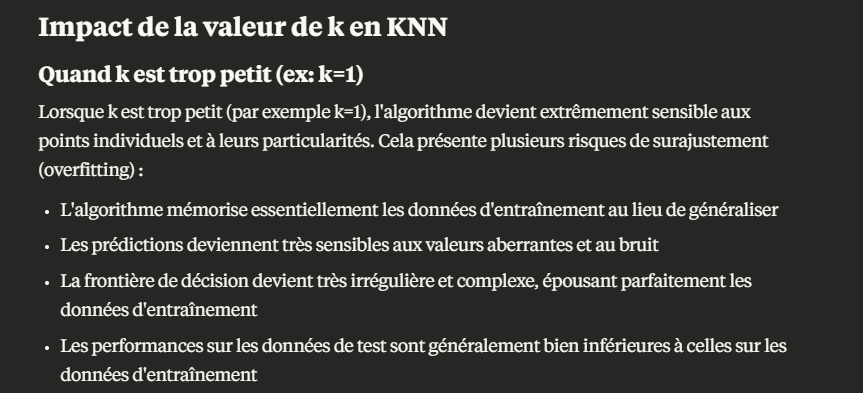

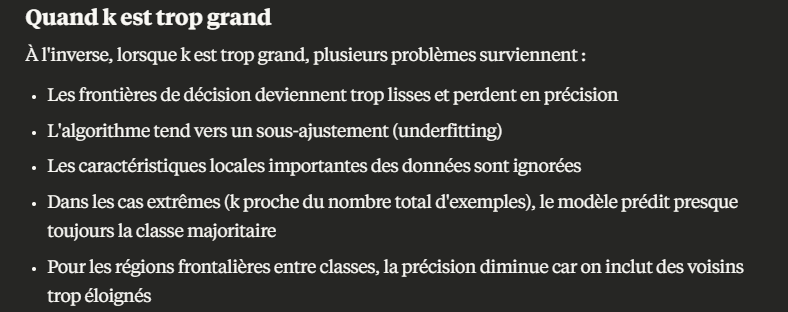

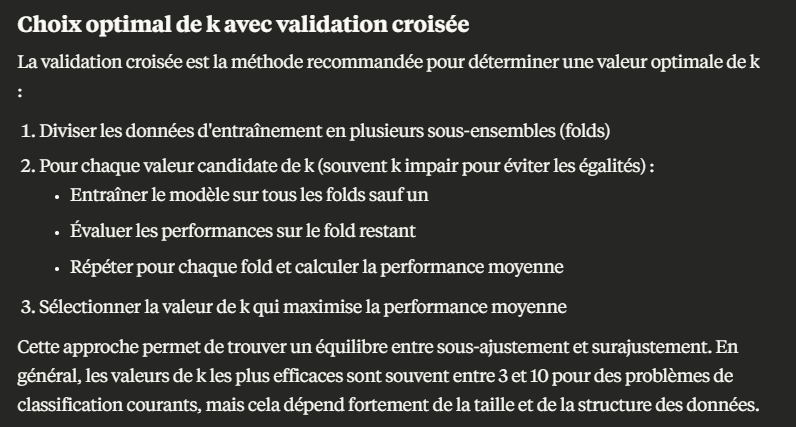

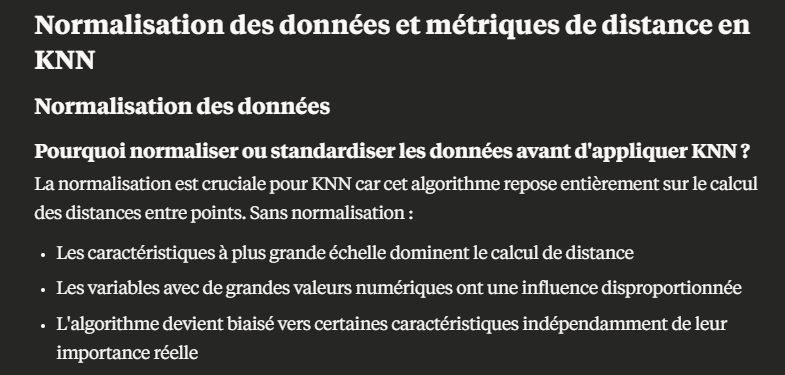

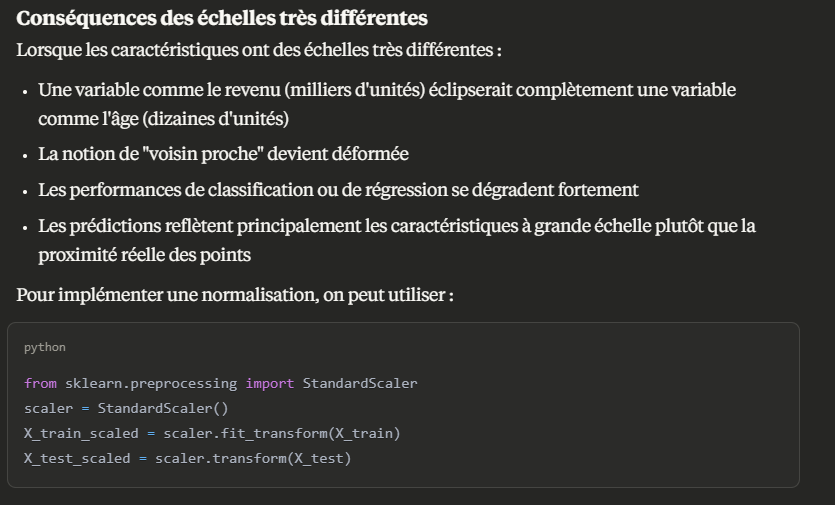

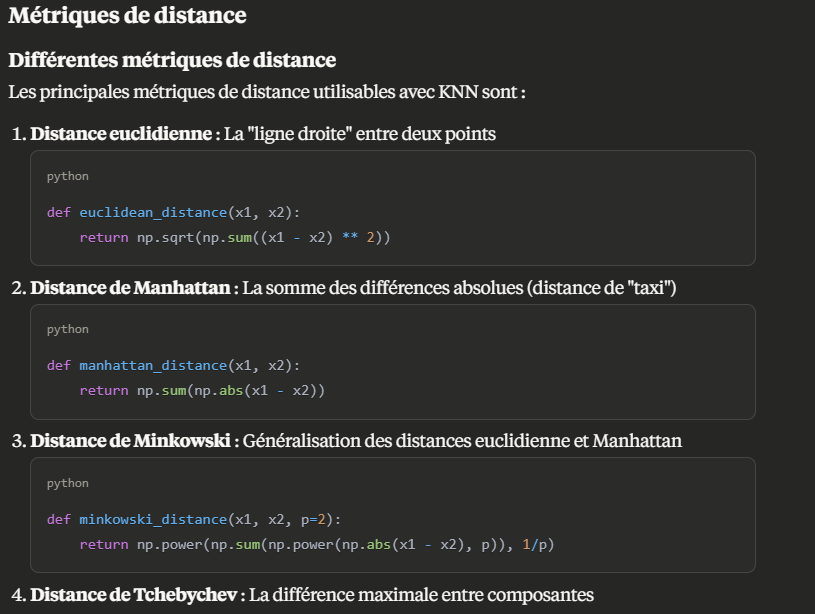

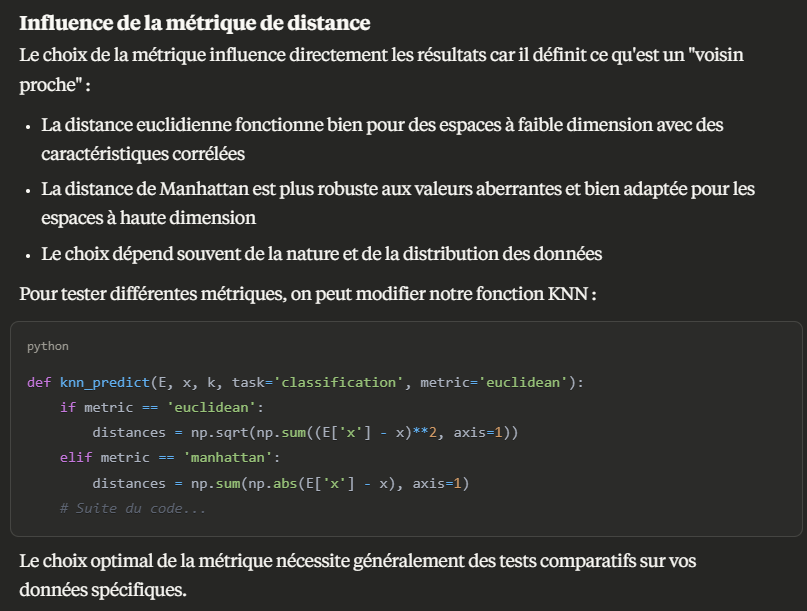

**Exercice 2 : Prediction de prix de l’immobilier**